# Classifier-Free Guidance (CFG)
### Conditional Diffusion Model from Scratch

---

## What is CFG?

CFG (Ho & Salimans 2022) is a method to **control what the diffusion model generates**.
Without CFG your model generates random digits. With CFG you can say *"generate a 7"* and it will.

---




## Core Idea — Run Model Twice

At every sampling step CFG runs the U-Net **twice**:

```
Run 1: model(xt, t, class=7)    → noise_cond    (knows it's a 7)
Run 2: model(xt, t, class=None) → noise_uncond  (no class info)
```

Then combines them with the **CFG formula**:

$$\epsilon_{final} = \epsilon_{uncond} + s \times (\epsilon_{cond} - \epsilon_{uncond})$$

Where **s = guidance scale** controls how strongly to follow the class:
```
s = 1.0  → weak  (almost random)
s = 7.5  → good  (clear digit) ✅
s = 15+  → too strong (artifacts)
```

---

## What Changes in Code

**Only 3 things change from DDIM:**

```
1. U-Net     → add class embedding, mix with time embedding
2. Training  → pass label into model + drop it 10% of time
3. Sampling  → run model twice + apply CFG formula
```

Loss function and noise schedule stay **exactly the same**.

---
## Step 1 — Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## Step 2 — Noise Schedule (same as DDPM/DDIM)

In [2]:
# ── Noise schedule ────────────────────────────────────────
T = 1000

betas                    = torch.linspace(1e-4, 0.02, T).to(device)
alphas                   = 1.0 - betas
alphas_cumprod           = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev      = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod          = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas            = torch.sqrt(1.0 / alphas)

print(f"Beta  range: {betas[0]:.5f} → {betas[-1]:.5f}")
print(f"ᾱ_t   range: {alphas_cumprod[0]:.5f} → {alphas_cumprod[-1]:.5f}")

Beta  range: 0.00010 → 0.02000
ᾱ_t   range: 0.99990 → 0.00004


---
## Step 3 — Helper Functions (same as before)

In [3]:
def extract(a, t, x_shape):
    """Extract schedule values at timestep t and reshape for broadcasting."""
    B   = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(B, *((1,) * (len(x_shape) - 1)))


def q_sample(x0, t, noise=None):
    """Forward process: xt = √ᾱ_t * x0 + √(1-ᾱ_t) * ε"""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab_t   = extract(sqrt_alphas_cumprod,            t, x0.shape)
    sqrt_1mab_t = extract(sqrt_one_minus_alphas_cumprod,  t, x0.shape)
    return sqrt_ab_t * x0 + sqrt_1mab_t * noise, noise

---
## Step 4 — CFG U-Net (CHANGED)

**Only one change from the original U-Net:**
Add a class embedding layer and mix it with the time embedding.

```
Before:  t_emb = time_mlp(t)
After:   t_emb = time_mlp(t) + class_emb(label)   ← just add together
```

The class embedding is a simple lookup table — one vector per digit (0-9).
We also add a special **null token** (index=10) for when no class is given (unconditioned).

In [4]:
# ── Sinusoidal Time Embedding ─────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -torch.arange(half, device=device) * (np.log(10000) / (half - 1))
        )
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


# ── Residual Block (unchanged) ────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


# ── CFG U-Net (class conditioning added) ─────────────────
class CFGUNet(nn.Module):
    """
    U-Net with class conditioning for CFG.

    Changes from SimpleUNet:
      1. class_emb: embedding table for 10 digits + 1 null token
      2. forward(): accepts class_label, adds class_emb to t_emb

    Null token (index=num_classes) is used for unconditioned pass.
    """
    def __init__(self, img_channels=1, base_ch=64, t_dim=128, num_classes=10):
        super().__init__()

        # ── Time embedding (same as before) ──────────────
        self.t_mlp = nn.Sequential(
            SinusoidalPE(t_dim),
            nn.Linear(t_dim, t_dim * 4),
            nn.SiLU(),
            nn.Linear(t_dim * 4, t_dim),
        )

        # ── Class embedding (NEW) ─────────────────────────
        # num_classes+1 because index=num_classes is the NULL token
        # NULL token = unconditioned pass (no class info)
        self.class_emb = nn.Embedding(num_classes + 1, t_dim)
        self.null_token = num_classes   # index 10 = "no class"

        ch = base_ch

        # ── Encoder (unchanged) ───────────────────────────
        self.init_conv = nn.Conv2d(img_channels, ch, 3, padding=1)
        self.pool      = nn.MaxPool2d(2)
        self.down1     = ResBlock(ch,   ch*2, t_dim)
        self.down2     = ResBlock(ch*2, ch*4, t_dim)

        # ── Bottleneck (unchanged) ────────────────────────
        self.bot1 = ResBlock(ch*4, ch*4, t_dim)
        self.bot2 = ResBlock(ch*4, ch*4, t_dim)

        # ── Decoder (unchanged) ───────────────────────────
        self.up1 = ResBlock(ch*4 + ch*2, ch*2, t_dim)
        self.up2 = ResBlock(ch*2 + ch,   ch,   t_dim)
        self.up  = nn.Upsample(scale_factor=2, mode='nearest')

        self.out = nn.Sequential(
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv2d(ch, img_channels, 1),
        )

    def forward(self, x, t, class_label=None):
        """
        Args:
            x:           noisy image [B, C, H, W]
            t:           timestep    [B]
            class_label: digit label [B] with values 0-9
                         or None for unconditioned pass
        """
        B = x.shape[0]

        # Time embedding
        t_emb = self.t_mlp(t)                                    # [B, t_dim]

        # Class embedding (NEW)
        if class_label is None:
            # Unconditioned — use null token for whole batch
            class_label = torch.full((B,), self.null_token,
                                     device=x.device, dtype=torch.long)
        c_emb = self.class_emb(class_label)                      # [B, t_dim]

        # Mix time + class embeddings — just add them together
        t_emb = t_emb + c_emb                                    # [B, t_dim]

        # ── Encoder ──────────────────────────────────────
        x1 = self.init_conv(x)                                   # [B, ch,   32, 32]
        x2 = self.down1(self.pool(x1), t_emb)                   # [B, ch*2, 16, 16]
        x3 = self.down2(self.pool(x2), t_emb)                   # [B, ch*4,  8,  8]

        # ── Bottleneck ────────────────────────────────────
        b  = self.bot2(self.bot1(x3, t_emb), t_emb)             # [B, ch*4,  8,  8]

        # ── Decoder ───────────────────────────────────────
        h  = self.up1(torch.cat([self.up(b), x2], dim=1), t_emb)  # [B, ch*2, 16, 16]
        h  = self.up2(torch.cat([self.up(h), x1], dim=1), t_emb)  # [B, ch,   32, 32]

        return self.out(h)                                        # [B, C, 32, 32]


# Initialize
model = CFGUNet(img_channels=1, base_ch=64, num_classes=10).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Sanity check
x_test = torch.randn(4, 1, 32, 32).to(device)
t_test = torch.randint(0, T, (4,)).to(device)
l_test = torch.randint(0, 10, (4,)).to(device)

out_cond   = model(x_test, t_test, l_test)   # conditioned
out_uncond = model(x_test, t_test, None)      # unconditioned
assert out_cond.shape == x_test.shape
assert out_uncond.shape == x_test.shape
print("Conditioned   forward pass OK ✅")
print("Unconditioned forward pass OK ✅")

Parameters: 4,586,689
Conditioned   forward pass OK ✅
Unconditioned forward pass OK ✅


---
## Step 5 — CFG Training (CHANGED)

**Only one change from DDPM/DDIM training:**
Randomly drop the class label 10% of the time.

```
90% of batches → pass real label     → model learns conditioned
10% of batches → pass null token     → model learns unconditioned
```

This teaches the model BOTH conditioned and unconditioned generation in one training run.
Loss function stays exactly the same: `MSE(pred_noise, noise)`

In [5]:
# ── Dataset ───────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)
print(f"Dataset: {len(dataset):,} images, {len(loader)} batches")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 520kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]

Dataset: 60,000 images, 469 batches



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [6]:
# ── CFG Training loop ─────────────────────────────────────
optimizer    = torch.optim.Adam(model.parameters(), lr=2e-4)
EPOCHS       = 50
DROP_PROB    = 0.1   # 10% chance to drop class label

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x0, labels in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x0     = x0.to(device)
        labels = labels.to(device)     # digit labels 0-9
        B      = x0.shape[0]

        # 1. Random timesteps
        t = torch.randint(0, T, (B,), device=device).long()

        # 2. Forward process — add noise
        noise  = torch.randn_like(x0)
        xt, _  = q_sample(x0, t, noise)

        # 3. Label dropout (CFG trick — NEW)
        # Randomly replace label with null token for 10% of samples
        drop_mask = torch.rand(B, device=device) < DROP_PROB     # [B] bool mask
        labels_dropped = labels.clone()
        labels_dropped[drop_mask] = model.null_token              # replace with null

        # 4. Predict noise with (possibly dropped) labels
        pred_noise = model(xt, t, labels_dropped)

        # 5. Loss — same MSE as always
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg = total_loss / len(loader)
    print(f"Epoch {epoch+1} | Loss: {avg:.4f}")

    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"cfg_model_epoch{epoch+1}.pt")
        print(f"  Checkpoint saved.")

Epoch 1/50:   0%|          | 0/469 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/50: 100%|██████████| 469/469 [00:46<00:00, 10.01it/s]


Epoch 1 | Loss: 0.0591


Epoch 2/50: 100%|██████████| 469/469 [00:51<00:00,  9.08it/s]


Epoch 2 | Loss: 0.0252


Epoch 3/50: 100%|██████████| 469/469 [00:53<00:00,  8.85it/s]


...

Epoch 48 | Loss: 0.0150


Epoch 49/50: 100%|██████████| 469/469 [00:52<00:00,  8.91it/s]


Epoch 49 | Loss: 0.0148


Epoch 50/50: 100%|██████████| 469/469 [00:52<00:00,  8.87it/s]

Epoch 50 | Loss: 0.0148
  Checkpoint saved.


---
## Step 6 — CFG Sampling (CHANGED)

**This is where CFG magic happens.**

At every step run the model **twice**:
```
noise_cond   = model(xt, t, class=7)    # knows it's a 7
noise_uncond = model(xt, t, class=None) # no class info
```

Apply CFG formula:
```
noise_final = noise_uncond + scale × (noise_cond - noise_uncond)
```

Then use `noise_final` to denoise (DDIM step).

In [7]:
# ── CFG DDIM step ─────────────────────────────────────────
@torch.no_grad()
def cfg_ddim_step(model, xt, t, t_prev, class_label, guidance_scale=7.5):
    """
    One CFG + DDIM denoising step.

    Args:
        xt:             noisy image at timestep t
        t:              current timestep tensor
        t_prev:         previous timestep tensor (or None)
        class_label:    digit to generate (e.g. tensor of 7s)
        guidance_scale: how strongly to follow the class (default 7.5)
    """
    # ── Run model TWICE ──────────────────────────────────
    # Conditioned: model knows the class
    noise_cond   = model(xt, t, class_label)    # ε_θ(xt, t, class)

    # Unconditioned: model gets null token
    noise_uncond = model(xt, t, None)            # ε_θ(xt, t, null)

    # ── CFG formula ──────────────────────────────────────
    # Push noise strongly toward the conditioned direction
    # ε_final = ε_uncond + scale × (ε_cond - ε_uncond)
    pred_noise = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

    # ── DDIM step using guided noise ─────────────────────
    sqrt_ab_t   = extract(sqrt_alphas_cumprod,            t, xt.shape)
    sqrt_1mab_t = extract(sqrt_one_minus_alphas_cumprod,  t, xt.shape)

    # Estimate clean image x0
    pred_x0 = (xt - sqrt_1mab_t * pred_noise) / sqrt_ab_t
    pred_x0 = pred_x0.clamp(-1, 1)

    # Final step
    if t_prev is None:
        return pred_x0

    # Jump to t_prev
    sqrt_ab_prev   = extract(sqrt_alphas_cumprod,           t_prev, xt.shape)
    sqrt_1mab_prev = extract(sqrt_one_minus_alphas_cumprod, t_prev, xt.shape)

    x_prev = sqrt_ab_prev * pred_x0 + sqrt_1mab_prev * pred_noise
    return x_prev


# ── CFG full sampling loop ────────────────────────────────
@torch.no_grad()
def sample_cfg(model, class_label, img_size=32, channels=1,
               n=16, ddim_steps=50, guidance_scale=7.5):
    """
    Generate images of a specific class using CFG + DDIM.

    Args:
        class_label:    digit to generate (0-9), single int
        guidance_scale: CFG strength (7.5 is a good default)
        ddim_steps:     number of DDIM steps
    """
    model.eval()

    # Start from pure noise
    x = torch.randn(n, channels, img_size, img_size).to(device)

    # Class label tensor — same class for all images
    labels = torch.full((n,), class_label, device=device, dtype=torch.long)

    # DDIM timestep subsequence
    timesteps = torch.linspace(0, T - 1, ddim_steps).long().flip(0).to(device)

    for i, t_now in enumerate(tqdm(timesteps,
                                   desc=f"CFG Sampling class={class_label} "
                                        f"scale={guidance_scale}")):
        t_tensor = torch.full((n,), t_now, device=device, dtype=torch.long)

        if i + 1 < len(timesteps):
            t_prev        = timesteps[i + 1]
            t_prev_tensor = torch.full((n,), t_prev, device=device, dtype=torch.long)
        else:
            t_prev_tensor = None

        x = cfg_ddim_step(model, x, t_tensor, t_prev_tensor,
                          labels, guidance_scale)

    x = (x.clamp(-1, 1) + 1) / 2
    return x

---
## Step 7 — Generate Specific Digits

CFG Sampling class=9 scale=7.5: 100%|██████████| 50/50 [00:00<00:00, 127.82it/s]


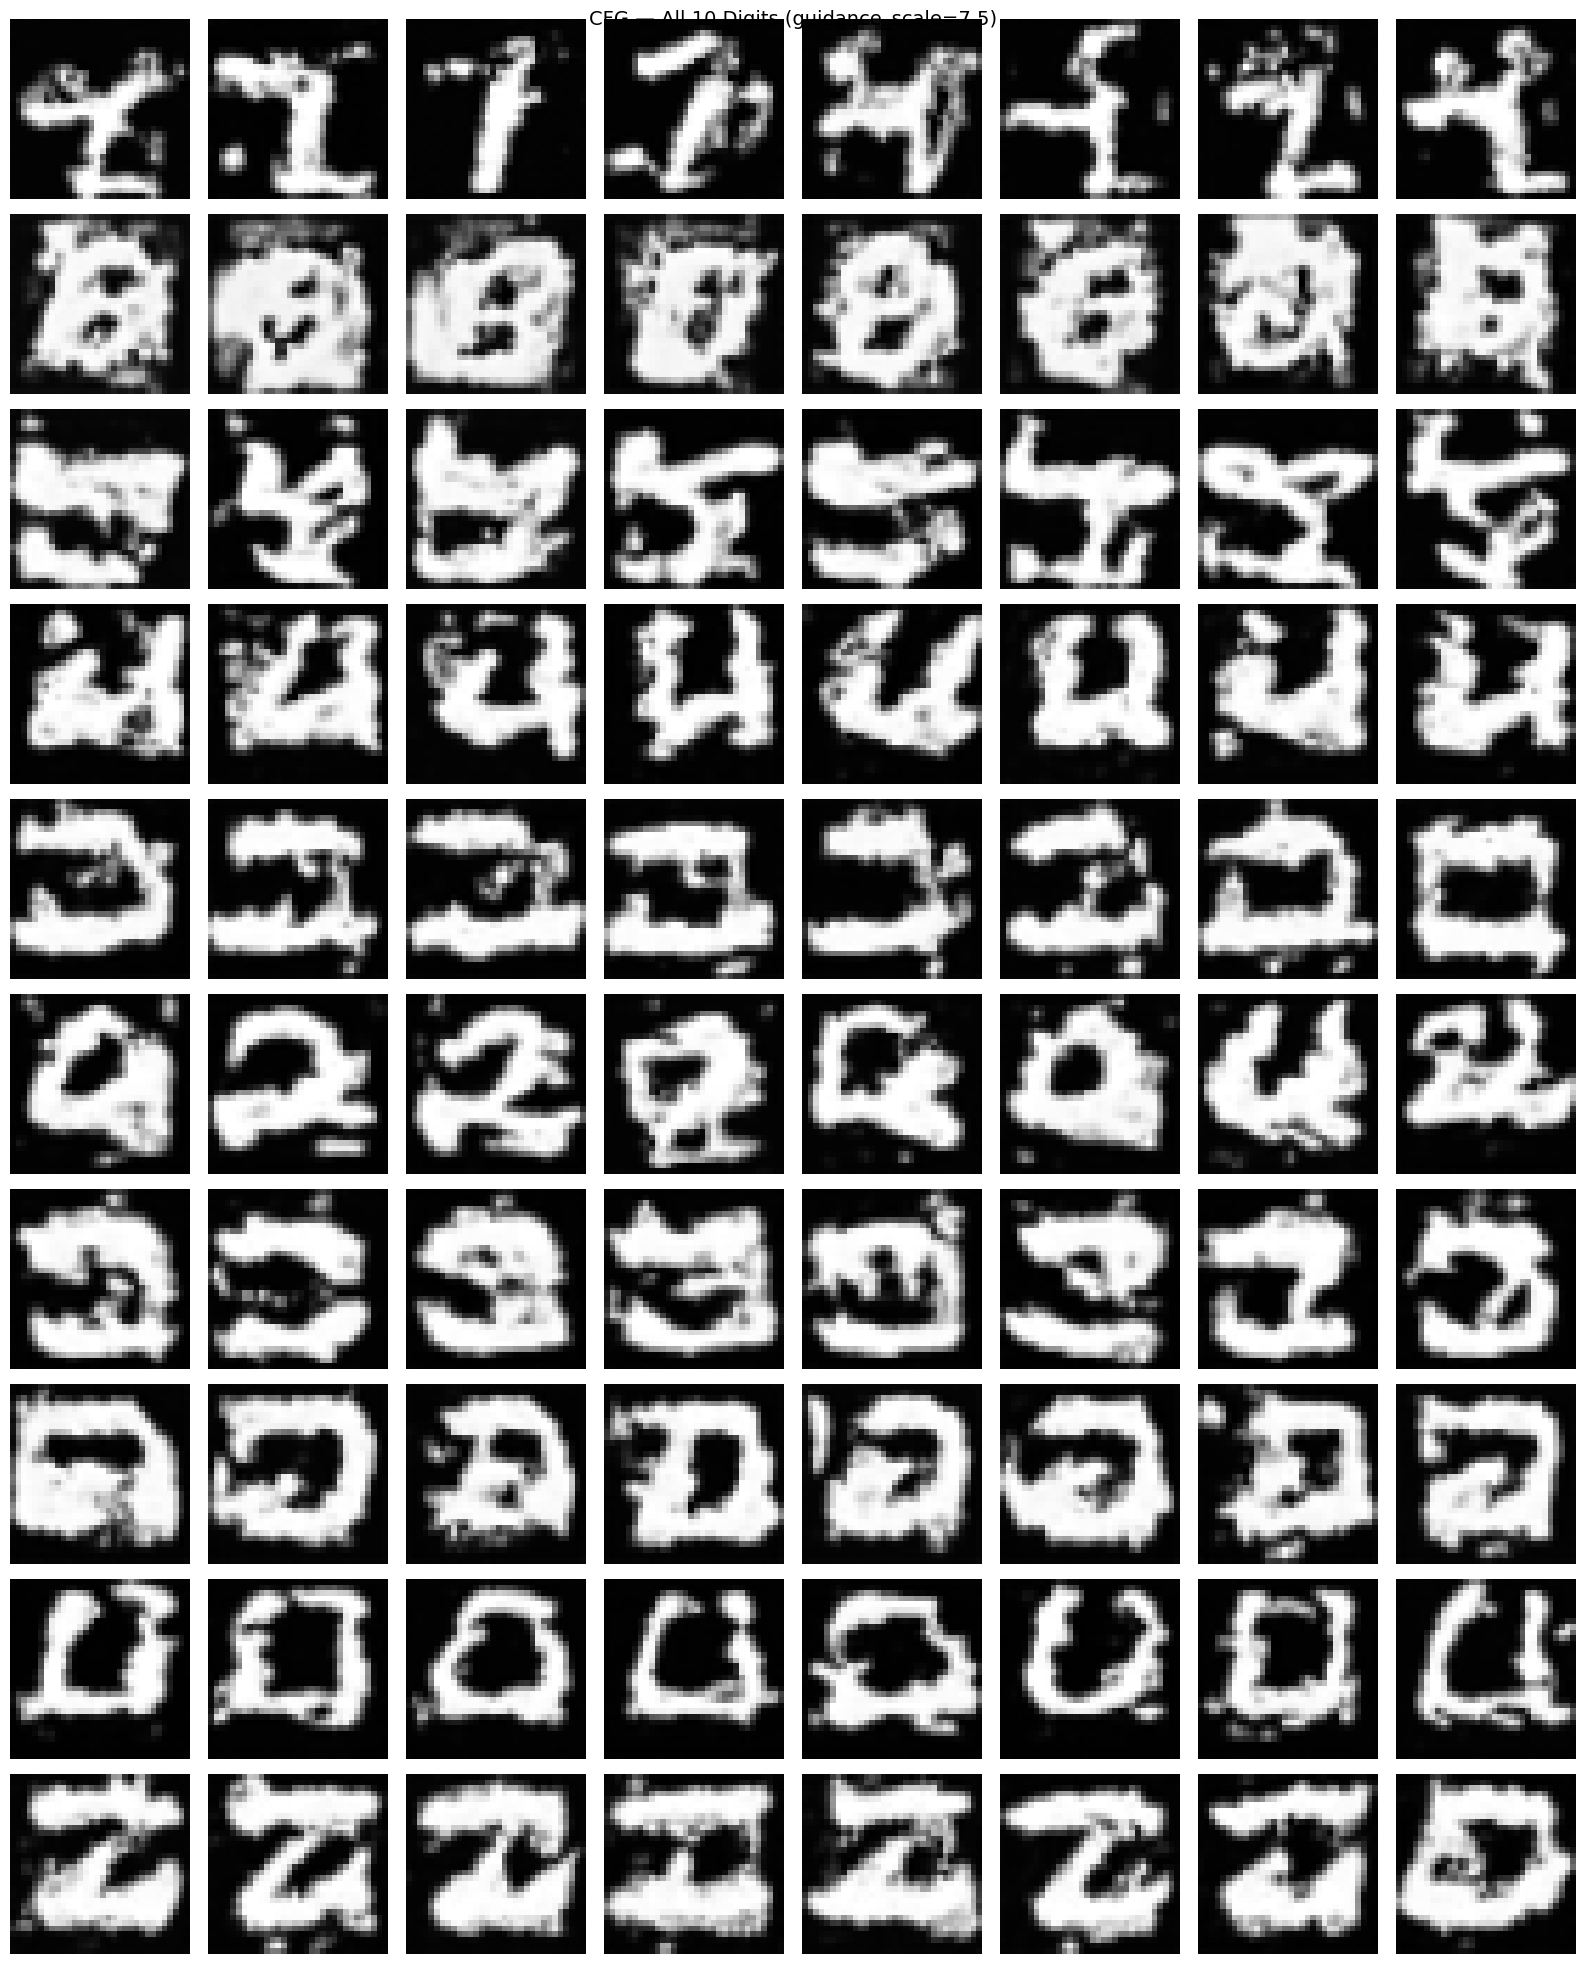

Saved: cfg_all_digits.png


In [8]:
# ── Generate all 10 digits ────────────────────────────────
fig, axes = plt.subplots(10, 8, figsize=(16, 20))

for digit in range(10):
    samples = sample_cfg(model, class_label=digit, n=8,
                         ddim_steps=50, guidance_scale=7.5)
    for col in range(8):
        axes[digit, col].imshow(samples[col, 0].cpu().numpy(), cmap='gray')
        axes[digit, col].axis('off')
    axes[digit, 0].set_ylabel(f'Digit {digit}', fontsize=10, rotation=0,
                               labelpad=40, va='center')

plt.suptitle('CFG — All 10 Digits (guidance_scale=7.5)', fontsize=14)
plt.tight_layout()
plt.savefig('cfg_all_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cfg_all_digits.png")

---
## Step 8 — Compare Guidance Scales

See how `guidance_scale` affects quality:
- Too low → blurry, ignores class(work better here)
- Just right → clear digit
- Too high → over-sharpened, artifacts

CFG Sampling class=7 scale=15.0: 100%|██████████| 50/50 [00:00<00:00, 133.27it/s]


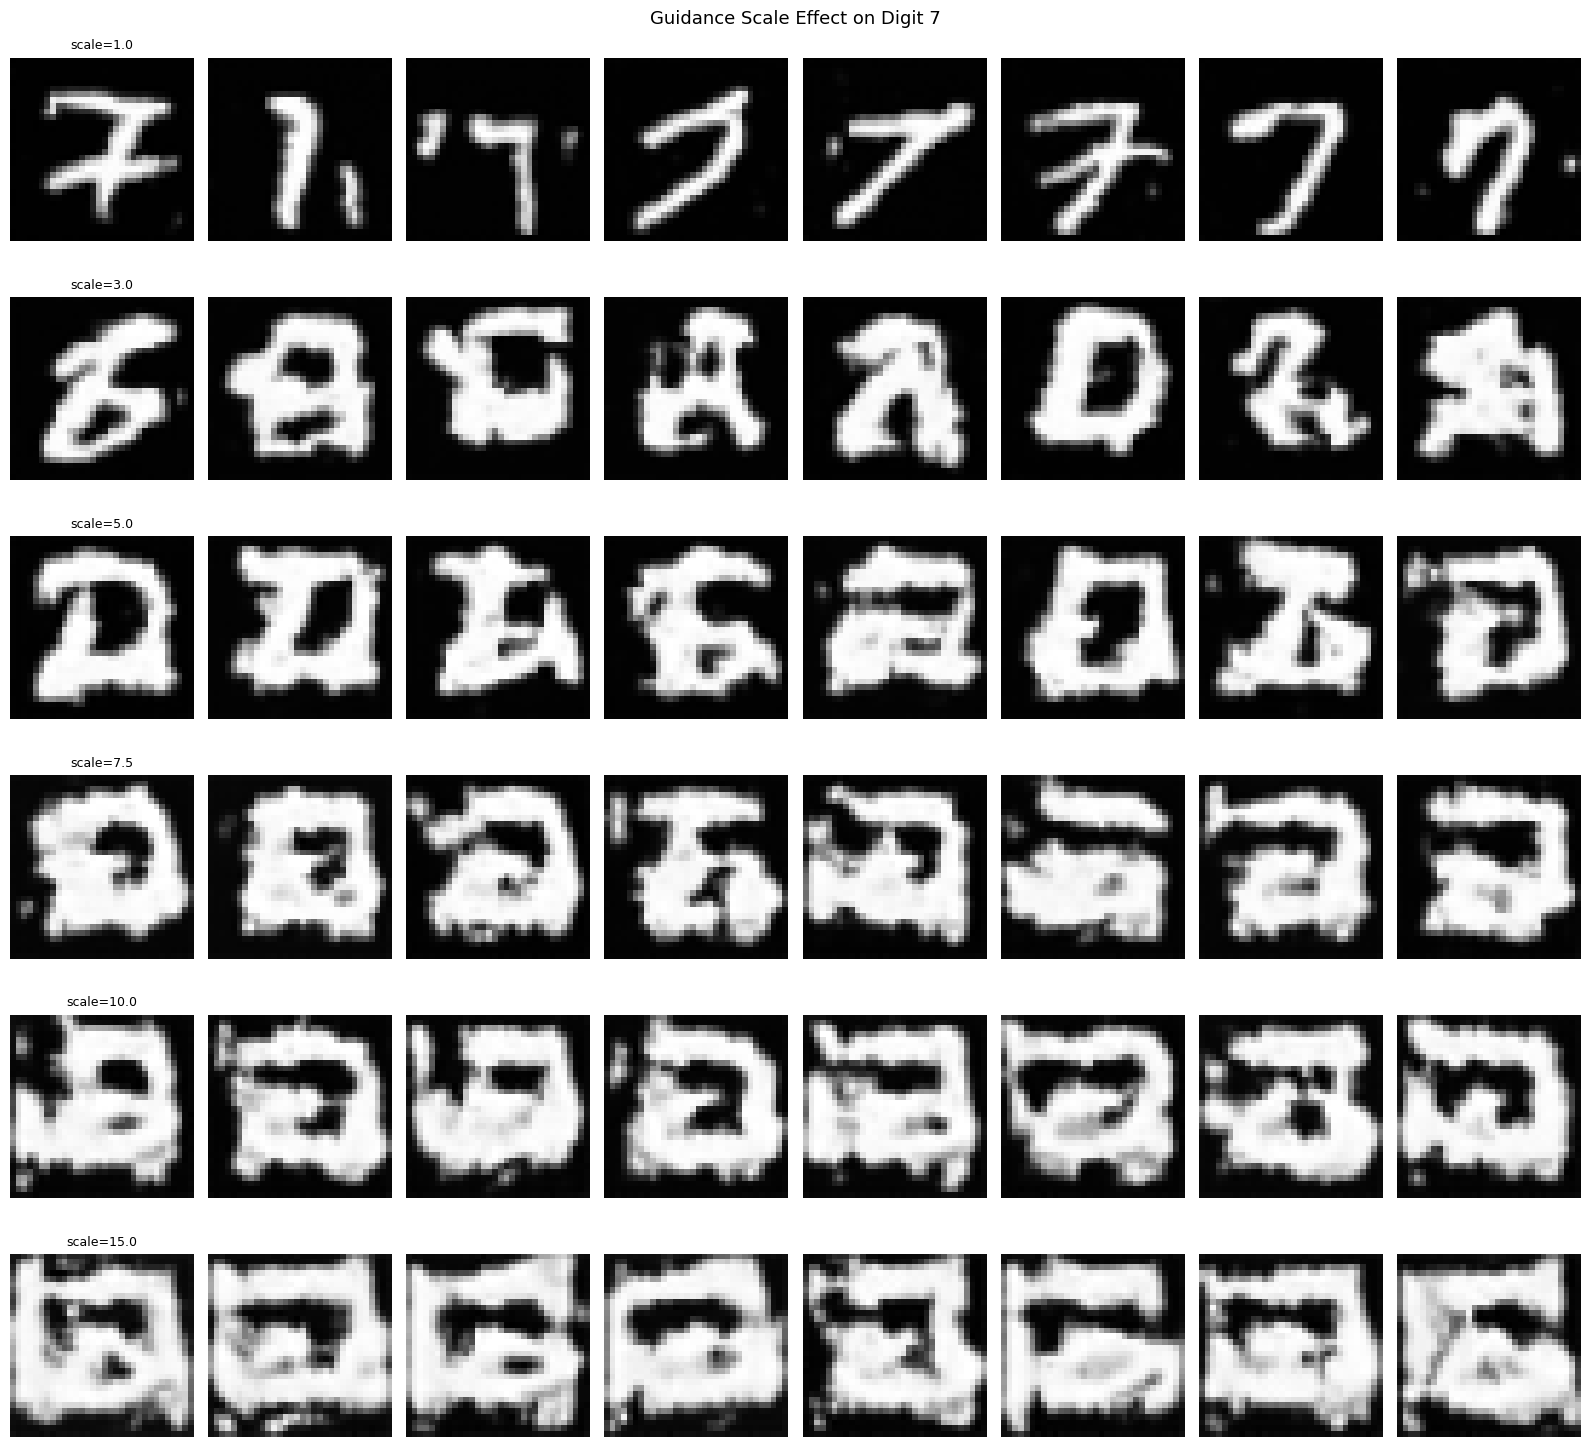

Saved: cfg_scale_comparison.png


In [9]:
# ── Guidance scale comparison ─────────────────────────────
scales  = [1.0, 3.0, 5.0, 7.5, 10.0, 15.0]
digit   = 7   # generate digit 7 at all scales

fig, axes = plt.subplots(len(scales), 8, figsize=(16, 2.5*len(scales)))

for row, scale in enumerate(scales):
    samples = sample_cfg(model, class_label=digit, n=8,
                         ddim_steps=50, guidance_scale=scale)
    for col in range(8):
        axes[row, col].imshow(samples[col, 0].cpu().numpy(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_title(f'scale={scale}', fontsize=9)

plt.suptitle(f'Guidance Scale Effect on Digit {digit}', fontsize=13)
plt.tight_layout()
plt.savefig('cfg_scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cfg_scale_comparison.png")

---
## Step 9 — Conditioned vs Unconditioned vs CFG

Compare three modes side by side to see what CFG actually does.

CFG Sampling class=3 scale=7.5: 100%|██████████| 50/50 [00:00<00:00, 130.35it/s]


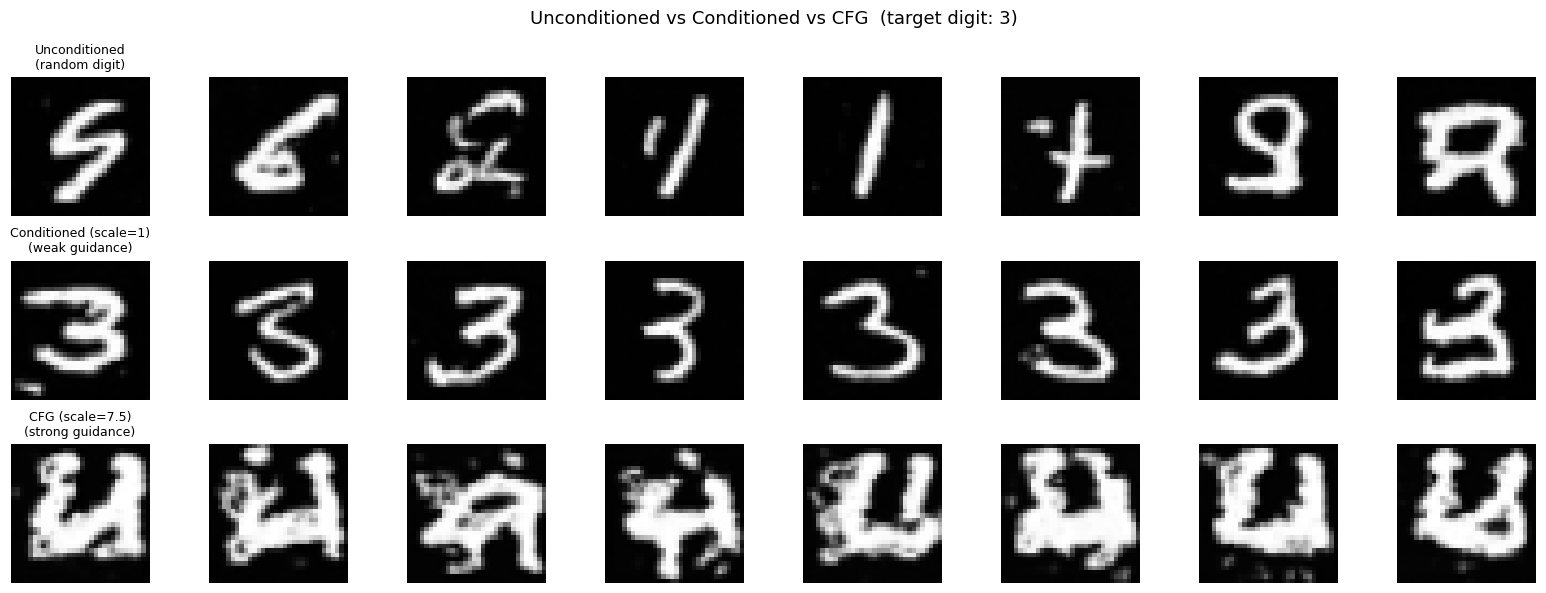

Saved: cfg_comparison.png


In [10]:
# ── Three mode comparison ─────────────────────────────────
@torch.no_grad()
def sample_conditioned_only(model, class_label, n=8, ddim_steps=50):
    """Conditioned but NO CFG — guidance_scale=1.0 (no amplification)"""
    return sample_cfg(model, class_label, n=n,
                      ddim_steps=ddim_steps, guidance_scale=1.0)


@torch.no_grad()
def sample_unconditioned(model, n=8, ddim_steps=50):
    """Fully unconditioned — random digit, no class info"""
    model.eval()
    x         = torch.randn(n, 1, 32, 32).to(device)
    timesteps = torch.linspace(0, T-1, ddim_steps).long().flip(0).to(device)

    for i, t_now in enumerate(tqdm(timesteps, desc="Unconditioned")):
        t_tensor      = torch.full((n,), t_now, device=device, dtype=torch.long)
        t_prev_tensor = (torch.full((n,), timesteps[i+1], device=device, dtype=torch.long)
                         if i+1 < len(timesteps) else None)

        sqrt_ab_t   = extract(sqrt_alphas_cumprod,           t_tensor, x.shape)
        sqrt_1mab_t = extract(sqrt_one_minus_alphas_cumprod, t_tensor, x.shape)
        pred_noise  = model(x, t_tensor, None)                # null token
        pred_x0     = (x - sqrt_1mab_t * pred_noise) / sqrt_ab_t
        pred_x0     = pred_x0.clamp(-1, 1)

        if t_prev_tensor is None:
            x = pred_x0
        else:
            sqrt_ab_p   = extract(sqrt_alphas_cumprod,           t_prev_tensor, x.shape)
            sqrt_1mab_p = extract(sqrt_one_minus_alphas_cumprod, t_prev_tensor, x.shape)
            x = sqrt_ab_p * pred_x0 + sqrt_1mab_p * pred_noise

    return (x.clamp(-1, 1) + 1) / 2


# Generate all three
digit = 3
uncond_samples = sample_unconditioned(model, n=8)
cond_samples   = sample_conditioned_only(model, class_label=digit, n=8)
cfg_samples    = sample_cfg(model, class_label=digit, n=8,
                             guidance_scale=7.5)

# Plot
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
titles    = ['Unconditioned\n(random digit)',
             f'Conditioned (scale=1)\n(weak guidance)',
             f'CFG (scale=7.5)\n(strong guidance)']

for col in range(8):
    for row, (samples, title) in enumerate(zip(
            [uncond_samples, cond_samples, cfg_samples], titles)):
        axes[row, col].imshow(samples[col, 0].cpu().numpy(), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(title, fontsize=9)

plt.suptitle(f'Unconditioned vs Conditioned vs CFG  (target digit: {digit})',
             fontsize=13)
plt.tight_layout()
plt.savefig('cfg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cfg_comparison.png")

### Note : Here small scale work better